In [1]:
%pip install pandas
%pip install scikit-learn
%pip install tensorflow
%pip install matplotlib
%pip install imbalanced-learn
%env SCIPY_ARRAY_API=1
%pip install xgboost lightgbm numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
env: SCIPY_ARRAY_API=1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 12.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [lightgbm]
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 📦 Imports
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.data_utils import load_and_preprocess_data
from src.model import build_weighted_model  # make sure this is imported
import csv
import pandas as pd
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
import joblib


In [3]:
# 1. Load and preprocess the data
(X_train, X_test, y_train, y_test), scaler = load_and_preprocess_data("../data/dataset.csv")
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

In [5]:
# ✅ 2. Load trained CNN-RNN model and get predictions
from tensorflow.keras.models import load_model
model = load_model("../results/cnn_rnn_model.h5")
cnn_train_probs = model.predict(X_train).flatten()
cnn_test_probs = model.predict(X_test).flatten()

  1/250 ━━━━━━━━━━━━━━━━━━━━ 36s 147ms/step

2025-06-26 11:17:51.764939: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [9]:
# ✅ 3. Train XGBoost on flat input

from xgboost import XGBClassifier
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_flat, y_train)
xgb_train_probs = xgb.predict_proba(X_train_flat)[:, 1]
xgb_test_probs = xgb.predict_proba(X_test_flat)[:, 1]

/Users/LucaZagaia/.pyenv/versions/3.10.13/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [11:19:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [10]:
# ✅ 4. Create meta-features for logistic regression
meta_X_train = np.vstack([cnn_train_probs, xgb_train_probs]).T
meta_X_test = np.vstack([cnn_test_probs, xgb_test_probs]).T

In [12]:
# ✅ 5. Train logistic regression as meta-learner
from sklearn.linear_model import LogisticRegression
meta_learner = LogisticRegression()
meta_learner.fit(meta_X_train, y_train)
ensemble_probs = meta_learner.predict_proba(meta_X_test)[:, 1]


📊 Ensemble Classification Report:

              precision    recall  f1-score   support

           0     0.9882    0.9964    0.9923      1939
           1     0.8444    0.6230    0.7170        61

    accuracy                         0.9850      2000
   macro avg     0.9163    0.8097    0.8546      2000
weighted avg     0.9838    0.9850    0.9839      2000



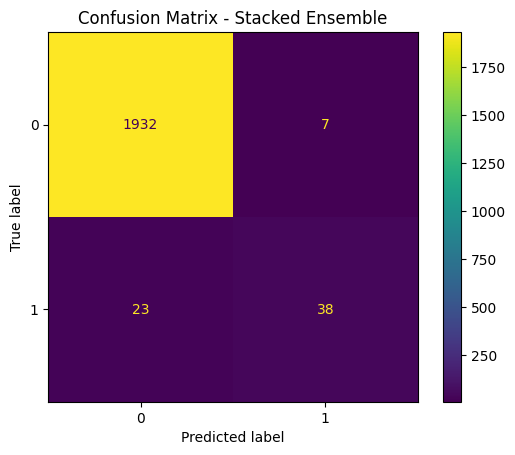

In [13]:
# ✅ 6. Final prediction and evaluation
threshold = 0.36  # Same threshold as before
y_pred = (ensemble_probs > threshold).astype(int)

print("\n📊 Ensemble Classification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix - Stacked Ensemble")
plt.grid(False)
plt.show()